# Chapter 8 — Diffusion for Inverse Problems

**Theory reference**: `quickguide.tex` Chapter 8.

### Problem setup
An inverse problem seeks to recover a clean signal $x_0$ from a degraded measurement:
$$y = \mathcal{A}(x_0) + n, \qquad n \sim \mathcal{N}(0, \sigma_y^2 I)$$
where $\mathcal{A}: \mathbb{R}^d \to \mathbb{R}^m$ is a known forward operator.  
Without a prior $p(x)$, this is ill-posed. Diffusion models provide a powerful **learned prior**.

### Posterior score decomposition (Bayes)
By Bayes' theorem:
$$\nabla_{x_0}\log p(x_0|y) = \underbrace{\nabla_{x_0}\log p(y|x_0)}_{\text{likelihood score}} + \underbrace{\nabla_{x_0}\log p(x_0)}_{\text{prior score (DDPM)}}$$

The **prior score** is available from a pretrained diffusion model.  
The **likelihood score** requires evaluating $p(y|x_0)$, but $x_0$ is only accessible at $t=0$.  

### DPS — Diffusion Posterior Sampling (Chung et al., 2022)
Approximate the intractable $p(y|x_t)$ via Tweedie's formula:
$$p(y|x_t) \approx p\bigl(y\,\big|\,\hat{x}_0(x_t,t)\bigr)$$
where $\hat{x}_0 = (x_t - \sigma_t\,\hat{\varepsilon}_\theta(x_t,t)) / \sqrt{\bar{\alpha}_t}$ is the Tweedie denoised estimate.

**DPS reverse update** (one step $t \to t-1$):
$$x_{t-1} = \underbrace{\mu_\theta(x_t,t) + \tilde{\sigma}_t z}_{\text{standard DDPM step}} - \underbrace{\frac{\zeta}{\|y - \mathcal{A}(\hat{x}_0)\|}\,\nabla_{x_t}\|y-\mathcal{A}(\hat{x}_0)\|^2}_{\text{DPS likelihood correction}}$$

The gradient is computed via autograd through the network: $x_t \to \hat{\varepsilon}_\theta \to \hat{x}_0 \to \mathcal{A}(\hat{x}_0) \to \|y - \mathcal{A}(\hat{x}_0)\|^2$.

### Inverse problems demonstrated
1. **Inpainting** — random pixel mask (50% missing) + box mask
2. **Gaussian deblurring** — Gaussian kernel $K$, $\mathcal{A}(x) = K * x$
3. **4× Super-resolution** — $\mathcal{A}(x) = \text{bicubic-downsample}(x, 4)$

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


## 0  Load / prepare DDPM model

We reuse the DDPM trained in notebook 05. If no checkpoint exists, we train a quick version.

In [2]:
from diffusion_lab.data       import get_mnist_loader, denormalize
from diffusion_lab.nn         import SmallUNet
from diffusion_lab.models     import DDPM
from diffusion_lab.schedulers import cosine_vp_schedule
from diffusion_lab.training   import Trainer

T = 1000
train_loader = get_mnist_loader(split='train', batch_size=128, num_workers=0)
test_loader  = get_mnist_loader(split='test',  batch_size=64,  num_workers=0)

unet = SmallUNet(in_channels=1, out_channels=1,
                 base_channels=32, time_embed_dim=128, dropout=0.1).to(DEVICE)
ddpm = DDPM(unet, cosine_vp_schedule(T=T).to(DEVICE), prediction='epsilon').to(DEVICE)

ckpt_path = pathlib.Path('../checkpoints/ddpm_mnist.pt')
if ckpt_path.exists():
    trainer_ref = Trainer(ddpm, train_loader, device=DEVICE)
    trainer_ref.load(str(ckpt_path))
    print(f'Loaded DDPM checkpoint from {ckpt_path}')
else:
    print('No checkpoint found — training DDPM for 20k steps ...')
    trainer_ref = Trainer(ddpm, train_loader, lr=2e-4, grad_clip=1.0, device=DEVICE)
    trainer_ref.train(n_steps=20_000, log_every=2000)

ddpm.eval()
sched = ddpm.schedule

Loaded DDPM checkpoint from ../checkpoints/ddpm_mnist.pt


## 1  Linear forward operators $\mathcal{A}$

We define each operator as a Python callable: `A(x) → y` and `A_T(r) → x` (adjoint, for display).

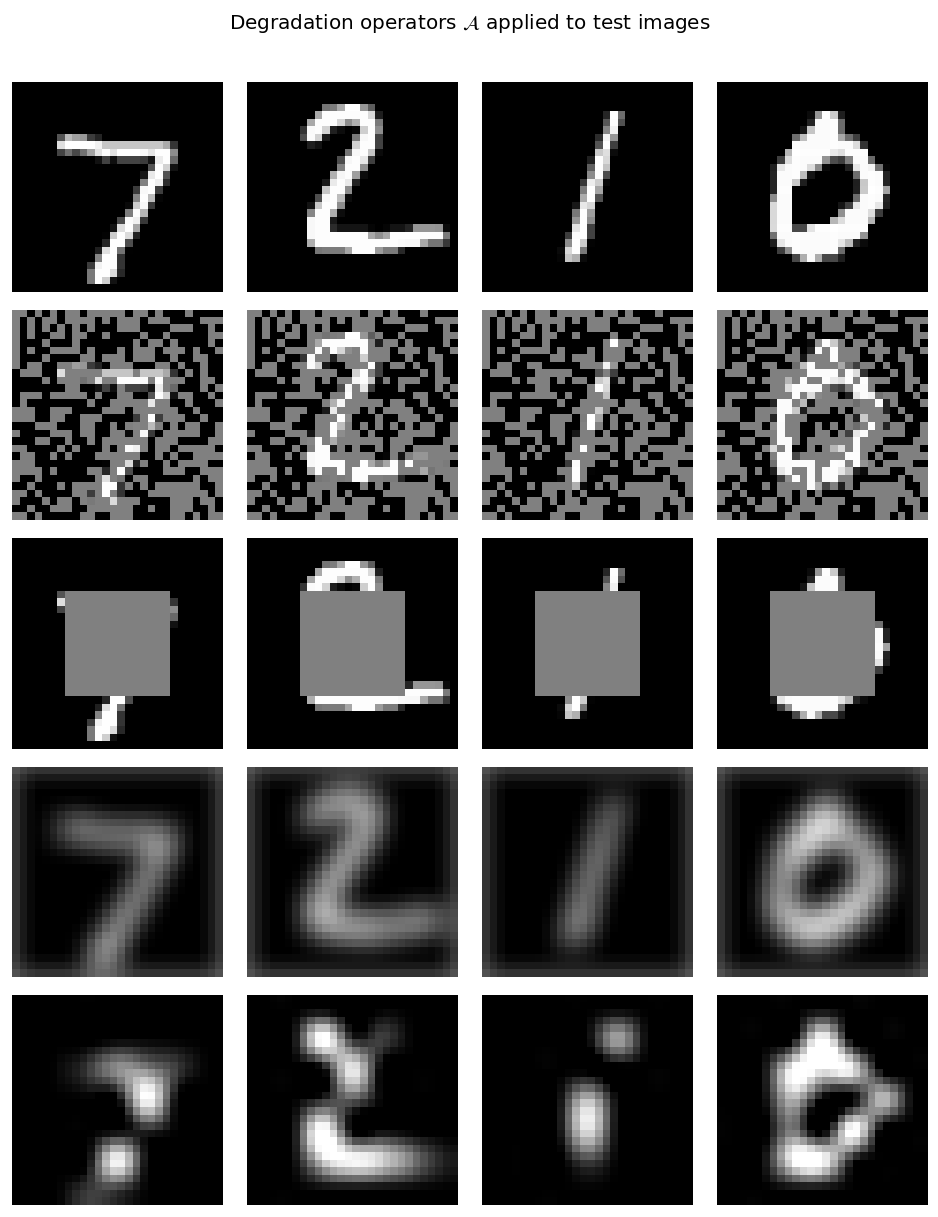

In [3]:
# -----------------------------------------------------------------------
# 1.1  Inpainting — random pixel mask
# -----------------------------------------------------------------------

def make_random_mask(shape, keep_frac=0.5, seed=0, device='cpu'):
    """Binary mask: 1 = keep, 0 = erase.  Shape: (1, 1, H, W) for broadcasting."""
    torch.manual_seed(seed)
    mask = (torch.rand(1, 1, *shape[-2:]) < keep_frac).float().to(device)
    return mask

def make_box_mask(shape, device='cpu'):
    """Erase centre quarter of image."""
    H, W = shape[-2], shape[-1]
    mask = torch.ones(1, 1, H, W, device=device)
    h0, h1 = H // 4, 3 * H // 4
    w0, w1 = W // 4, 3 * W // 4
    mask[:, :, h0:h1, w0:w1] = 0.0
    return mask


# -----------------------------------------------------------------------
# 1.2  Gaussian blur operator
# -----------------------------------------------------------------------

def gaussian_kernel(ksize=7, sigma=1.5, device='cpu'):
    """Returns (1, 1, ksize, ksize) Gaussian kernel."""
    coords = torch.arange(ksize, dtype=torch.float32, device=device) - ksize // 2
    g1d    = torch.exp(-coords ** 2 / (2 * sigma ** 2))
    g1d   /= g1d.sum()
    kernel = g1d[:, None] * g1d[None, :]
    return kernel.unsqueeze(0).unsqueeze(0)   # (1, 1, ksize, ksize)

def blur_operator(x, kernel):
    """Apply Gaussian blur via depthwise conv2d.  x: (B,1,H,W)."""
    pad = kernel.shape[-1] // 2
    return F.conv2d(x, kernel.to(x.device), padding=pad, groups=x.shape[1])


# -----------------------------------------------------------------------
# 1.3  4× Super-resolution operator  (downsample then upsample)
# -----------------------------------------------------------------------

SR_FACTOR = 4

def sr_downsample(x):
    """Bicubic downsample by SR_FACTOR, returns low-res measurement.
    antialias=False for MPS compatibility (antialias=True is unsupported on MPS < PyTorch 2.2).
    """
    return F.interpolate(x, scale_factor=1.0/SR_FACTOR, mode='bicubic',
                         align_corners=False, antialias=False)

def sr_upsample_bicubic(x_lr):
    """Bicubic upsample (naive baseline)."""
    return F.interpolate(x_lr, scale_factor=float(SR_FACTOR), mode='bicubic',
                         align_corners=False)


# -----------------------------------------------------------------------
# Quick visualisation of each degradation on one test image
# -----------------------------------------------------------------------

x0_demo, _ = next(iter(test_loader))
x0_demo    = x0_demo[:4].to(DEVICE)

blur_k   = gaussian_kernel(ksize=7, sigma=2.0, device=DEVICE)
rand_mask = make_random_mask(x0_demo.shape, keep_frac=0.5, seed=42, device=DEVICE)
box_mask  = make_box_mask(x0_demo.shape, device=DEVICE)

y_inpaint_rand = x0_demo * rand_mask
y_inpaint_box  = x0_demo * box_mask
y_blur         = blur_operator(x0_demo, blur_k)
y_lr           = sr_downsample(x0_demo)
y_lr_up        = sr_upsample_bicubic(y_lr)   # bicubic baseline

rows = {
    'Clean $x_0$':            x0_demo,
    'Inpaint (random 50%)':   y_inpaint_rand,
    'Inpaint (box mask)':     y_inpaint_box,
    'Gaussian blur (σ=2)':    y_blur,
    'Bicubic ×4 upsampled':   y_lr_up,
}

fig, axes = plt.subplots(len(rows), 4, figsize=(8, len(rows)*2))
for row_i, (title, imgs) in enumerate(rows.items()):
    for col in range(4):
        axes[row_i, col].imshow(denormalize(imgs[col]).squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
        axes[row_i, col].axis('off')
    axes[row_i, 0].set_ylabel(title, rotation=0, labelpad=120, va='center', fontsize=8)

fig.suptitle('Degradation operators $\\mathcal{A}$ applied to test images', y=1.01)
plt.tight_layout()
plt.show()

## 2  DPS — Diffusion Posterior Sampling

### Algorithm

At each reverse step $t$, DPS adds a gradient correction to the standard DDPM update:

$$\boxed{x_{t-1} = \mu_\theta(x_t,t) + \tilde{\sigma}_t z - \frac{\zeta_t}{\|r_t\|}\,\nabla_{x_t}\|r_t\|^2}, \qquad r_t = y - \mathcal{A}(\hat{x}_0(x_t,t))$$

The gradient $\nabla_{x_t}\|r_t\|^2$ flows through the network $\hat{\varepsilon}_\theta$  
via the chain $x_t \xrightarrow{\text{net}} \hat{x}_0 \xrightarrow{\mathcal{A}} r_t \xrightarrow{\|\cdot\|^2} \mathbb{R}$.

**Step-size schedule**: $\zeta_t = \zeta / \|r_t\|$ (self-normalised, from the DPS paper).

In [4]:
def dps_sample(
    ddpm,
    y: torch.Tensor,
    operator_A,
    zeta: float = 1.0,
    device: str = 'cpu',
    verbose: bool = True,
    log_every: int = 100,
    sample_shape: tuple | None = None,
):
    """
    DPS sampler (Chung et al., 2022) for linear inverse problems.

    Parameters
    ----------
    ddpm         : trained DDPM (with .network, .schedule, .p_sample)
    y            : (B, ...) degraded measurement (may differ in shape from x0)
    operator_A   : callable, y_hat = A(x0_hat)
    zeta         : step-size numerator for the gradient correction
    device       : torch device string
    sample_shape : explicit shape for x (B, C, H, W). Required when y is in a
                   different space from x0 (e.g. super-resolution: y is 7×7,
                   x0 is 28×28). Defaults to y.shape.

    Returns
    -------
    x0_hat : (B, C, H, W) reconstructed clean image
    """
    ddpm.eval()
    sched  = ddpm.schedule
    T_sched = sched.T
    y = y.to(device)

    if sample_shape is not None:
        B, C, H, W = sample_shape
    else:
        B, C, H, W = y.shape

    # Initialise from Gaussian noise
    x = torch.randn(B, C, H, W, device=device)

    for t in range(T_sched, 0, -1):
        # -----------------------------------------------------------
        # (a) Enable autograd for the likelihood gradient
        # -----------------------------------------------------------
        x_in = x.detach().requires_grad_(True)

        t_tensor = torch.full((B,), t, dtype=torch.long, device=device)
        t_norm   = t_tensor.float() / T_sched

        # Tweedie: x̂_0 = (x_t − σ_t · ε̂) / √ᾱ_t
        ab_t  = sched.alpha_bar[t].to(device)
        sig_t = sched.sigma[t].to(device)       # √(1 − ᾱ_t)

        eps_hat = ddpm.network(x_in, t_norm)             # (B, C, H, W)
        x0_hat  = (x_in - sig_t * eps_hat) / ab_t.sqrt() # Tweedie estimate
        x0_hat  = x0_hat.clamp(-5.0, 5.0)               # stability

        # -----------------------------------------------------------
        # (b) Likelihood gradient ∇_{x_t} ‖y − A(x̂_0)‖²
        # -----------------------------------------------------------
        residual   = y - operator_A(x0_hat)              # (B, *)
        loss_ll    = (residual ** 2).flatten(1).sum(dim=1).mean()
        loss_ll.backward()

        grad_xt    = x_in.grad.detach()                  # ∇_{x_t}
        norm_r     = residual.detach().flatten(1).norm(dim=1, keepdim=True)
        norm_r     = norm_r.view(B, 1, 1, 1).clamp(min=1e-8)

        # -----------------------------------------------------------
        # (c) Standard DDPM reverse step p(x_{t-1} | x_t)
        # -----------------------------------------------------------
        with torch.no_grad():
            x_prev = ddpm.p_sample(x.detach(), t)        # (B, C, H, W)

            # DPS correction (self-normalised step)
            x_prev = x_prev - (zeta / norm_r) * grad_xt

        x = x_prev

        if verbose and t % log_every == 0:
            r_mean = residual.detach().abs().mean().item()
            print(f'  t={t:4d}  |r|_mean={r_mean:.4f}')

    return x.detach()

### Helper — comparison panel

Displays `[degraded | DPS reconstruction | ground truth]` for a batch of images.

In [5]:
def show_inverse_results(y_degraded, x_recon, x_gt, task_name, n_show=8):
    """
    Display degraded | DPS | ground truth side by side.
    For super-resolution, y_degraded is the low-res image (upsampled for display).
    """
    n_show = min(n_show, x_gt.shape[0])
    fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.5, 5))

    row_labels = [f'Measurement $y$\n({task_name})', 'DPS reconstruction', 'Ground truth $x_0$']
    imgs_list  = [y_degraded, x_recon, x_gt]

    for row, (label, imgs) in enumerate(zip(row_labels, imgs_list)):
        for col in range(n_show):
            img = denormalize(imgs[col]).squeeze().cpu().clamp(0, 1)
            axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(label, rotation=0, labelpad=110, va='center', fontsize=8)

    # Per-image PSNR
    mse   = ((denormalize(x_recon[:n_show]) - denormalize(x_gt[:n_show])) ** 2).flatten(1).mean(1)
    psnr  = (-10 * torch.log10(mse + 1e-8)).mean().item()
    fig.suptitle(f'DPS — {task_name}   (avg PSNR ≈ {psnr:.1f} dB)', y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()
    return psnr

## 3  Experiment 1 — Random-pixel Inpainting

**Forward operator**: $\mathcal{A}(x_0) = M \odot x_0$, where $M \in \{0,1\}^{H\times W}$ is a random binary mask retaining 50% of pixels.

**Likelihood**: $p(y|x_0) = \mathcal{N}(y; M \odot x_0, \sigma_y^2 I)$

In [6]:
N_INP = 8   # number of images to reconstruct

# Get test images
x0_gt, _ = next(iter(test_loader))
x0_gt    = x0_gt[:N_INP].to(DEVICE)

# Create fixed random mask (same mask for all images in batch)
mask_rand = make_random_mask(x0_gt.shape, keep_frac=0.5, seed=99, device=DEVICE)
y_inp     = x0_gt * mask_rand   # masked measurement

# DPS: A(x) = mask * x
A_inpaint = lambda x: mask_rand * x

print('Running DPS — random inpainting (this takes a few minutes)...')
x_inp_recon = dps_sample(
    ddpm, y_inp, A_inpaint,
    zeta=1.0, device=DEVICE, verbose=True, log_every=200,
)
print('Done.')

Running DPS — random inpainting (this takes a few minutes)...
  t=1000  |r|_mean=2.2195
  t= 800  |r|_mean=0.0492
  t= 600  |r|_mean=0.0231
  t= 400  |r|_mean=0.0137
  t= 200  |r|_mean=0.0069
Done.


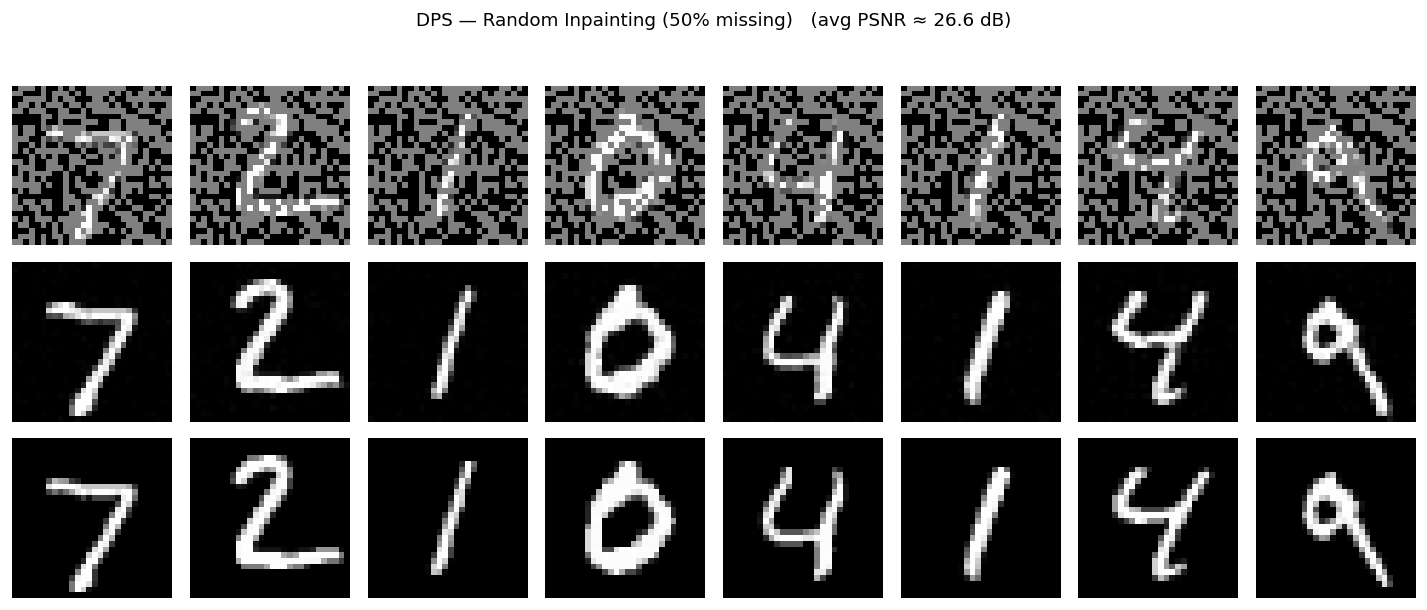

In [7]:
psnr_inp = show_inverse_results(
    y_inp, x_inp_recon, x0_gt,
    task_name='Random Inpainting (50% missing)',
)

## 4  Experiment 2 — Box (centre) Inpainting

The box mask is a harder problem than random masking: the centre 14×14 region is completely unobserved,
so the model must hallucinate plausible digit structure from context alone.

In [8]:
mask_box = make_box_mask(x0_gt.shape, device=DEVICE)
y_box    = x0_gt * mask_box

A_box = lambda x: mask_box * x

print('Running DPS — box inpainting ...')
x_box_recon = dps_sample(
    ddpm, y_box, A_box,
    zeta=1.0, device=DEVICE, verbose=True, log_every=200,
)
print('Done.')

Running DPS — box inpainting ...
  t=1000  |r|_mean=3.2649
  t= 800  |r|_mean=0.0561
  t= 600  |r|_mean=0.0265
  t= 400  |r|_mean=0.0151
  t= 200  |r|_mean=0.0084
Done.


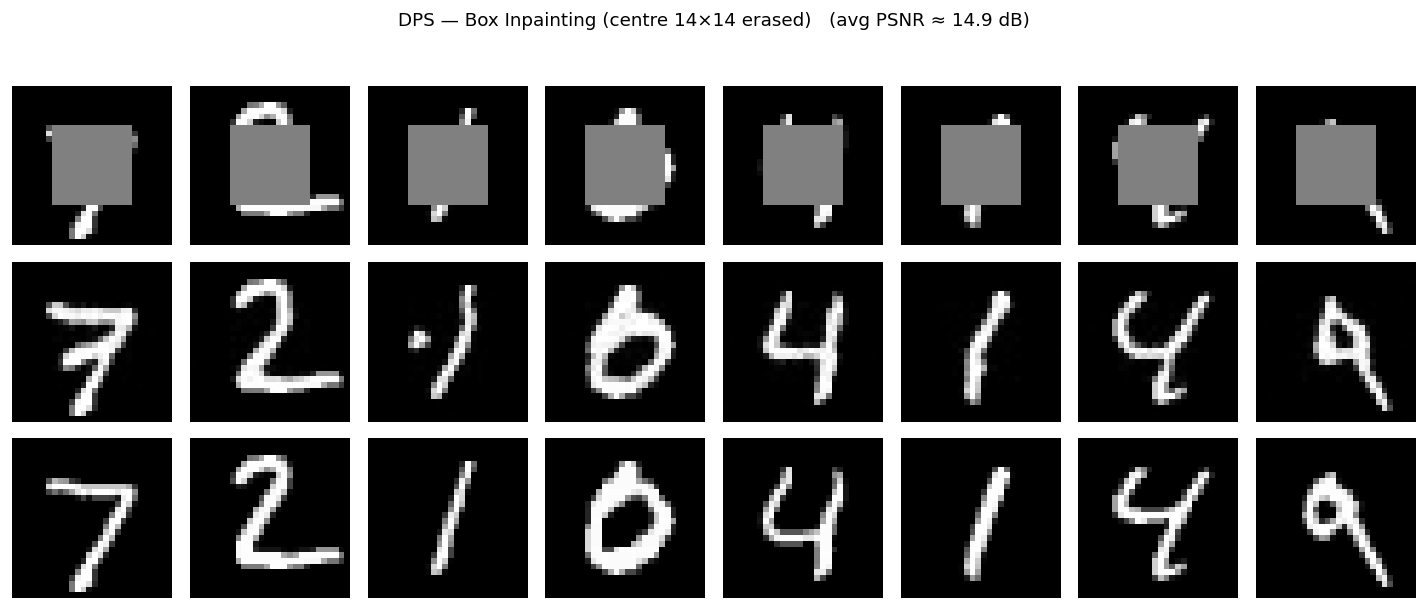

In [9]:
psnr_box = show_inverse_results(
    y_box, x_box_recon, x0_gt,
    task_name='Box Inpainting (centre 14×14 erased)',
)

## 5  Experiment 3 — Gaussian Deblurring

**Forward operator**: $\mathcal{A}(x_0) = K * x_0$, where $K$ is a $7\times7$ Gaussian kernel with $\sigma=2$.

This is a _non-trivial_ deconvolution problem: the blur kernel is not invertible in the presence of noise.

In [10]:
blur_kernel = gaussian_kernel(ksize=7, sigma=2.0, device=DEVICE)
A_blur      = lambda x: blur_operator(x, blur_kernel)

y_blur_gt = A_blur(x0_gt)  # blurred measurement

print('Running DPS — Gaussian deblurring ...')
x_blur_recon = dps_sample(
    ddpm, y_blur_gt, A_blur,
    zeta=0.5,   # smaller step size — blur is a smoother forward op
    device=DEVICE, verbose=True, log_every=200,
)
print('Done.')

Running DPS — Gaussian deblurring ...
  t=1000  |r|_mean=2.1036
  t= 800  |r|_mean=0.0430
  t= 600  |r|_mean=0.0184
  t= 400  |r|_mean=0.0096
  t= 200  |r|_mean=0.0056
Done.


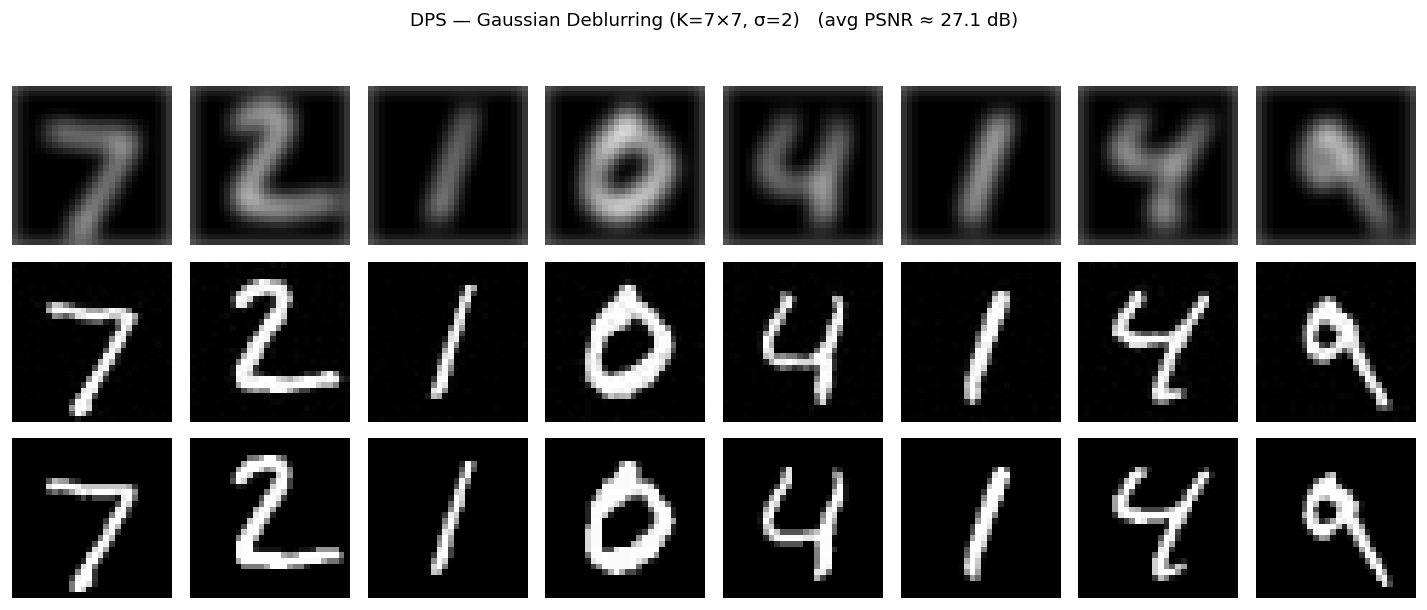

In [11]:
psnr_blur = show_inverse_results(
    y_blur_gt, x_blur_recon, x0_gt,
    task_name='Gaussian Deblurring (K=7×7, σ=2)',
)

## 6  Experiment 4 — 4× Super-Resolution

**Forward operator**: $\mathcal{A}(x_0) = \text{Bicubic}_{\downarrow 4}(x_0)$  (28×28 → 7×7 → back to 28×28 for loss computation).

In DPS, the operator $\mathcal{A}$ only needs to produce $y$; the residual $\|y - \mathcal{A}(\hat{x}_0)\|^2$ is computed in **measurement space** (7×7 here).

**Naive baseline**: bicubic upsampling of the 7×7 LR image (no learned prior).

In [12]:
# Measurement: 7×7 LR image
y_lr_meas = sr_downsample(x0_gt)   # (B, 1, 7, 7)

# For DPS: A(x_hr) = avg_pool downsample → residual in LR space (differentiable on MPS)
A_sr = lambda x: F.avg_pool2d(x, kernel_size=SR_FACTOR, stride=SR_FACTOR)

# Bicubic baseline for comparison
y_bicubic = sr_upsample_bicubic(y_lr_meas)   # (B, 1, 28, 28)

print('Running DPS — 4× super-resolution ...')
x_sr_recon = dps_sample(
    ddpm, y_lr_meas, A_sr,
    zeta=0.7, device=DEVICE, verbose=True, log_every=200,
    sample_shape=(y_lr_meas.shape[0], 1, 28, 28),   # HR shape, not LR shape
)
print('Done.')

Running DPS — 4× super-resolution ...
  t=1000  |r|_mean=2.3495
  t= 800  |r|_mean=0.1919
  t= 600  |r|_mean=0.1277
  t= 400  |r|_mean=0.0956
  t= 200  |r|_mean=0.0705
Done.


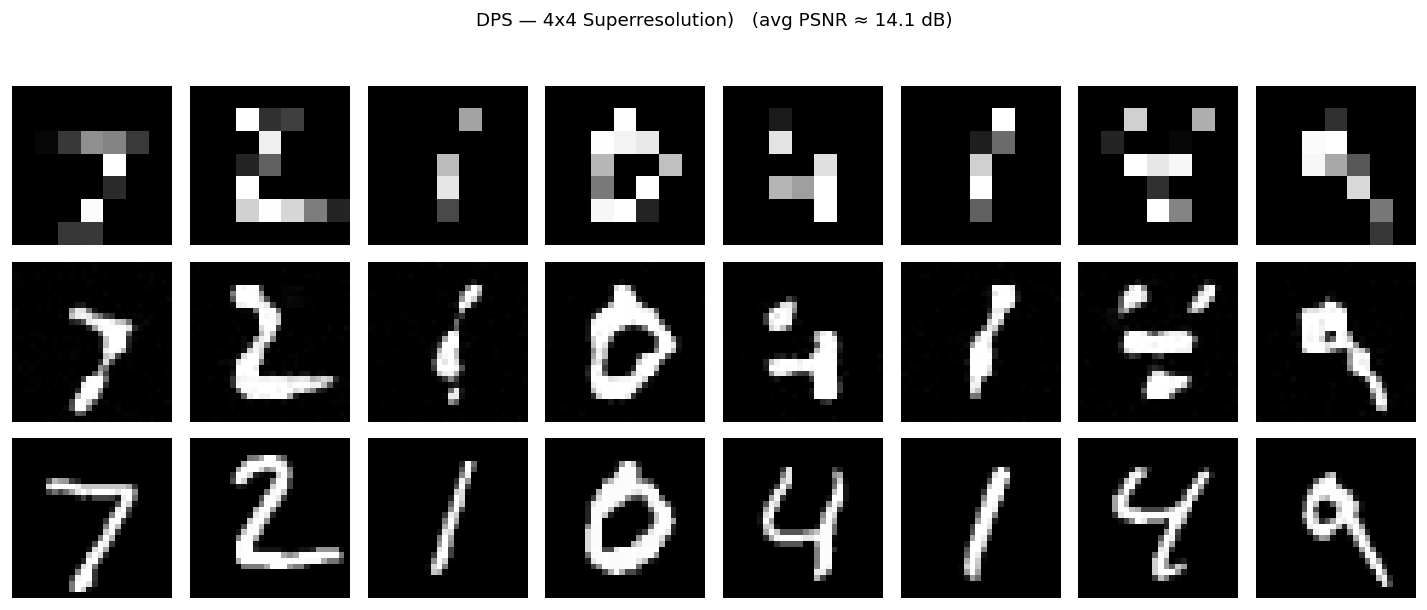

In [13]:
psnr_sr = show_inverse_results(
    y_lr_meas, x_sr_recon, x0_gt,
    task_name='4x4 Superresolution)',
)

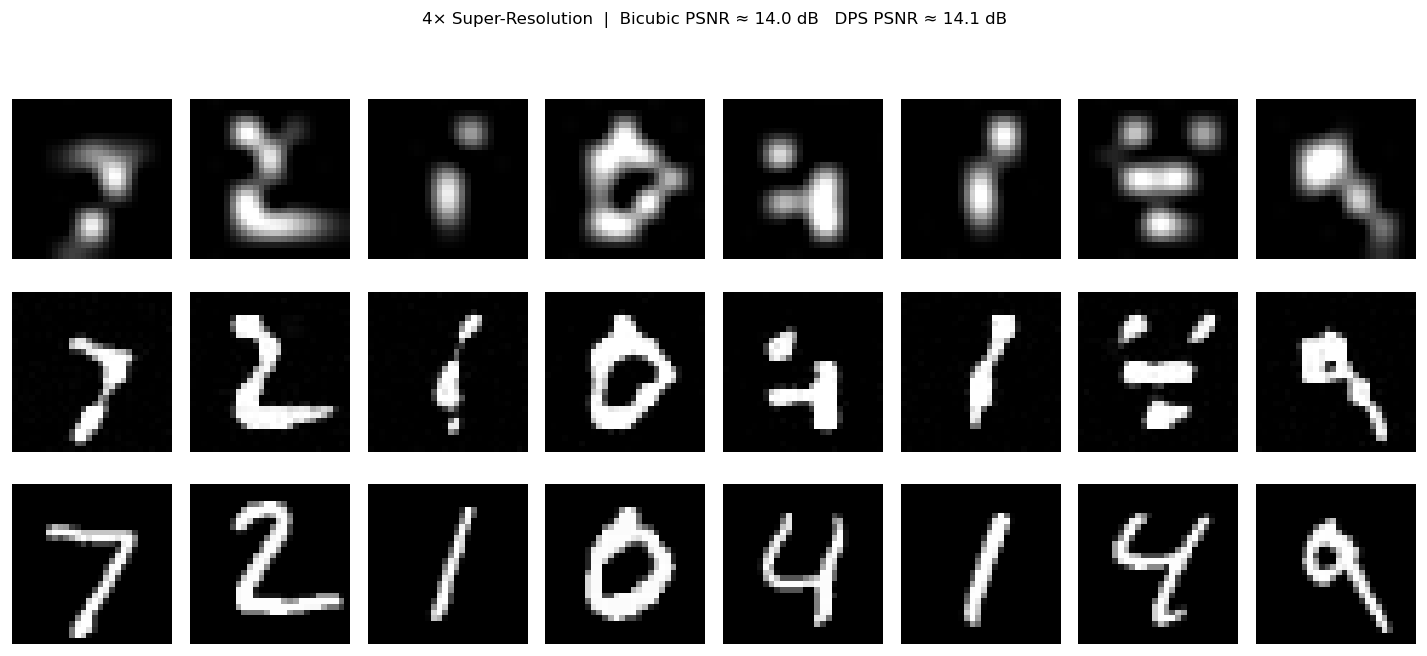

In [14]:
# Show 3-way comparison: bicubic | DPS | ground truth
N = min(8, x0_gt.shape[0])
fig, axes = plt.subplots(3, N, figsize=(N * 1.5, 5.5))

row_labels = ['Bicubic ×4 (baseline)', 'DPS reconstruction', 'Ground truth $x_0$']
imgs_list  = [y_bicubic, x_sr_recon, x0_gt]

for row, (label, imgs) in enumerate(zip(row_labels, imgs_list)):
    for col in range(N):
        img = denormalize(imgs[col]).squeeze().cpu().clamp(0, 1)
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(label, rotation=0, labelpad=115, va='center', fontsize=8)

# PSNR for both methods
def psnr_batch(x_hat, x_gt, n):
    mse = ((denormalize(x_hat[:n]) - denormalize(x_gt[:n]))**2).flatten(1).mean(1)
    return (-10*torch.log10(mse+1e-8)).mean().item()

p_bic = psnr_batch(y_bicubic, x0_gt, N)
p_dps = psnr_batch(x_sr_recon, x0_gt, N)
fig.suptitle(f'4× Super-Resolution  |  Bicubic PSNR ≈ {p_bic:.1f} dB   DPS PSNR ≈ {p_dps:.1f} dB',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

## 7  Summary — PSNR comparison across tasks

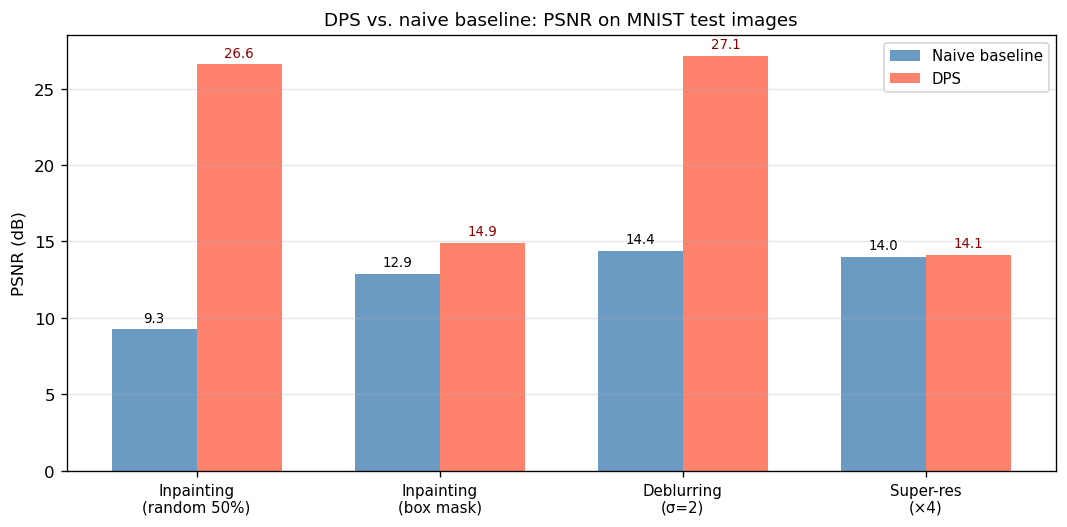


Results summary:
Task                           Naive (dB)   DPS (dB)     Gain
--------------------------------------------------------------
Inpainting (random 50%)              9.26      26.58   +17.32
Inpainting (box mask)               12.88      14.93    +2.05
Deblurring (σ=2)                    14.41      27.14   +12.73
Super-res (×4)                      14.02      14.12    +0.10


In [15]:
# Collect PSNR for naive baselines (zero-fill for inpainting, identity for blur)
def psnr_t(a, b):
    mse = ((denormalize(a) - denormalize(b))**2).flatten(1).mean(1)
    return (-10*torch.log10(mse+1e-8)).mean().item()

results = {
    'Inpainting\n(random 50%)':  (psnr_t(y_inp,       x0_gt), psnr_t(x_inp_recon, x0_gt)),
    'Inpainting\n(box mask)':    (psnr_t(y_box,       x0_gt), psnr_t(x_box_recon, x0_gt)),
    'Deblurring\n(σ=2)':         (psnr_t(y_blur_gt,   x0_gt), psnr_t(x_blur_recon, x0_gt)),
    'Super-res\n(×4)':           (psnr_t(y_bicubic,   x0_gt), psnr_t(x_sr_recon,  x0_gt)),
}

tasks   = list(results.keys())
naive   = [v[0] for v in results.values()]
dps_psnr = [v[1] for v in results.values()]

x_pos = np.arange(len(tasks))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))
bars1 = ax.bar(x_pos - width/2, naive,    width, label='Naive baseline', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, dps_psnr, width, label='DPS',            color='tomato',    alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(tasks, fontsize=9)
ax.set_ylabel('PSNR (dB)', fontsize=10)
ax.set_title('DPS vs. naive baseline: PSNR on MNIST test images', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, naive):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, dps_psnr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8, color='darkred')

plt.tight_layout()
plt.show()

print('\nResults summary:')
print(f'{"Task":<28} {"Naive (dB)":>12} {"DPS (dB)":>10} {"Gain":>8}')
print('-' * 62)
for task, (p_naive, p_dps) in results.items():
    print(f'{task.replace(chr(10)," "):<28} {p_naive:>12.2f} {p_dps:>10.2f} {p_dps-p_naive:>+8.2f}')

## 8  DPS stochasticity — multiple reconstructions of the same measurement

Because DPS is stochastic (inherits the stochasticity of DDPM ancestral sampling),  
different random seeds produce different valid reconstructions — all consistent with the measurement $y$.

This is a feature: DPS samples from the **posterior** $p(x_0|y)$, not a point estimate.

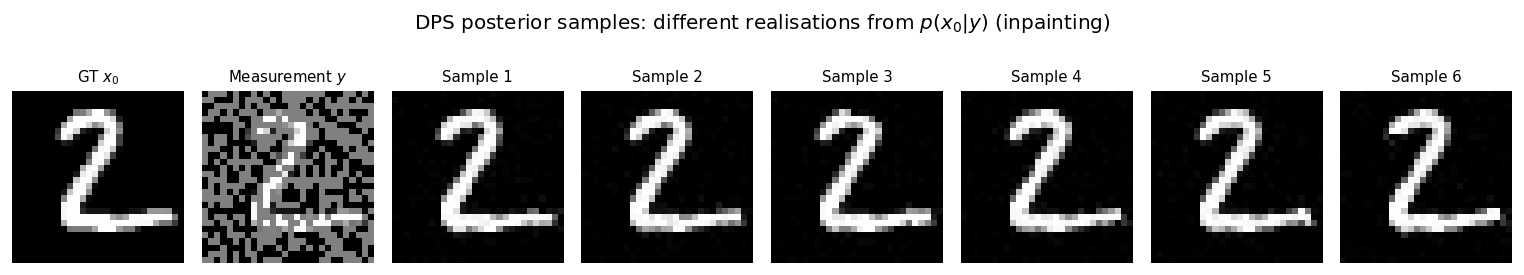

In [17]:
# Single measurement y, multiple reconstructions
x0_single = x0_gt[1:2]   # one image
y_single  = x0_single * mask_rand
N_SAMPLES = 6

recons = []
for seed in range(N_SAMPLES):
    torch.manual_seed(seed)
    x_r = dps_sample(ddpm, y_single, A_inpaint, zeta=1.0,
                     device=DEVICE, verbose=False)
    recons.append(x_r)

fig, axes = plt.subplots(1, N_SAMPLES + 2, figsize=((N_SAMPLES + 2) * 1.6, 2.2))
axes[0].imshow(denormalize(x0_single).squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('GT $x_0$', fontsize=9)
axes[0].axis('off')

axes[1].imshow(denormalize(y_single).squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Measurement $y$', fontsize=9)
axes[1].axis('off')

for i, x_r in enumerate(recons):
    axes[i + 2].imshow(denormalize(x_r).squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
    axes[i + 2].set_title(f'Sample {i+1}', fontsize=9)
    axes[i + 2].axis('off')

fig.suptitle('DPS posterior samples: different realisations from $p(x_0|y)$ (inpainting)', y=1.05)
plt.tight_layout()
plt.show()

## 9  Notes on DPS and alternatives

**DPS limitations:**
- Requires $T$ forward passes through the network with autograd → $\sim 2\times$ slower than unconditional DDPM sampling.
- The Tweedie approximation $p(y|x_t) \approx p(y|\hat{x}_0(x_t))$ introduces bias, especially at large $t$.
- Step size $\zeta$ must be tuned per operator; too large → mode collapse, too small → ignores measurement.

**Related methods (see quickguide Ch. 8):**

| Method | Key idea |
|---|---|
| **DPS** (Chung et al. 2022) | Gradient guidance via Tweedie + autograd |
| **DDRM** (Kawar et al. 2022) | SVD decomposition of $\mathcal{A}$; exact for linear Gaussian |
| **DDNM** (Wang et al. 2022) | Null-space projection: refine $\hat{x}_0$ onto $\mathcal{A}^{-1}(y)$ |
| **Repaint** (Lugmayr et al. 2022) | Inpainting only; resample known pixels from $q(x_t|x_0)$ at each step |
| **Π-GDM** (Song et al. 2023) | Proximal gradient; handles non-smooth operators |
| **PSLD / ReSample** (2023–24) | Latent diffusion extensions of DPS |